In [11]:
import pyodbc

# Replace these with your actual database credentials
server = 'LAPTOP-BJE2TQGI\KK'  # e.g., 'localhost' or '192.168.1.100'
database = 'add'  # e.g., 'SalesDB'


# Create a connection string
conn_str = f'DRIVER={{SQL Server}};SERVER={server};DATABASE={database}'

# Try connecting to the databaseimport pyodbc

# Replace with your actual details
server = 'LAPTOP-BJE2TQGI\KK'
database = 'add'

# Use Trusted Connection (Windows login)
conn_str = f'DRIVER={{SQL Server}};SERVER={server};DATABASE={database};Trusted_Connection=yes;'

try:
    conn = pyodbc.connect(conn_str)
    print("✅ Connection successful!")

    cursor = conn.cursor()

    # Query to list all tables in the database
    cursor.execute("SELECT TABLE_NAME FROM INFORMATION_SCHEMA.TABLES WHERE TABLE_TYPE='BASE TABLE'")

    print("📋 Tables in the database:")
    for row in cursor.fetchall():
        print("-", row.TABLE_NAME)

    conn.close()

except Exception as e:
    print("❌ Connection failed. Error:", e)

try:
    conn = pyodbc.connect(conn_str)
    print("Connection successful!")
    conn.close()  # Close the connection after testing
except Exception as e:
    print("Connection failed. Error:", e)

✅ Connection successful!
📋 Tables in the database:
- date
- Dim_bac
- Dim_Company
- Dim_Condidat
- Dim_condidature
- Dim_cursus
- Dim_date
- Dim_employer
- Dim_job
- Dim_parent
- Dim_region
- Dim_speciality
- Dim_University
- fact_a
- Fact_employbility
Connection successful!


# CLASSIFICATION RANDOMFOREST 

In [12]:
# %% [markdown]
# # Student Admission Prediction System (Single Classifier Version)

# %%
# Initial setup
import pyodbc
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

# %% [markdown]
# ## 1. Database Connection

# %%
def create_db_connection():
    server = 'LAPTOP-BJE2TQGI\KK'
    database = 'add'
    conn_str = f'DRIVER={{SQL Server}};SERVER={server};DATABASE={database};Trusted_Connection=yes;'
    try:
        conn = pyodbc.connect(conn_str)
        print("✅ Database connection successful!")
        return conn
    except Exception as e:
        print(f"❌ Connection failed. Error: {e}")
        return None

conn = create_db_connection()

# %% [markdown]
# ## 2. Load Data

# %%
def load_data(conn, table_name):
    try:
        query = f"SELECT * FROM {table_name}"
        df = pd.read_sql(query, conn)
        print(f"📊 Loaded {len(df)} records from {table_name}")
        return df
    except Exception as e:
        print(f"❌ Data loading failed: {e}")
        return None

bac_data = load_data(conn, 'Dim_bac')
if bac_data is not None:
    bac_data.head()

# %% [markdown]
# ## 3. Data Preparation

# %%
def prepare_features(df):
    df = df.copy()
    
    if 'date_bac' in df.columns:
        df['date_bac'] = pd.to_datetime(df['date_bac'], errors='coerce')
        df['year'] = df['date_bac'].dt.year
    
    if 'moy_bac_et' in df.columns and df['moy_bac_et'].dtype == 'object':
        df['moy_bac_et'] = df['moy_bac_et'].str.replace(',', '.').astype(float)
    
    if 'code_etab_bac' in df.columns:
        le = LabelEncoder()
        df['code_etab_bac_encoded'] = le.fit_transform(df['code_etab_bac'])
    
    if all(col in df.columns for col in ['code_etab_bac', 'moy_bac_et']):
        school_avg = df.groupby('code_etab_bac')['moy_bac_et'].mean().sort_values()
        df['school_tier'] = df['code_etab_bac'].map({school: i//3 for i, school in enumerate(school_avg.index)})
    
    return df

prepared_data = prepare_features(bac_data)
prepared_data.head()

# %% [markdown]
# ## 4. Simulate Missing Data (Temporary)

# %%
def simulate_missing_data(df, n_samples=1000):
    synthetic = df.sample(n_samples, replace=True)
    np.random.seed(42)
    
    synthetic['moy_bac_et'] = np.clip(synthetic['moy_bac_et'] + np.random.normal(0, 1, n_samples), 0, 20)
    synthetic['year'] = synthetic['year'] + np.random.randint(-2, 3, n_samples)
    
    bac_types = ['SCIENCE', 'LETTERS', 'MATH', 'SPORT', 'TECH']
    synthetic['nature_bac'] = np.random.choice(bac_types, n_samples)
    
    synthetic['admitted'] = ((synthetic['moy_bac_et'] > 12) & (np.random.random(n_samples) > 0.3)).astype(int)
    
    programs = ['INFO', 'GENICIV', 'ELECTRO', 'TELCOMM']
    synthetic['program'] = np.random.choice(programs, n_samples, p=[0.3, 0.25, 0.2, 0.25])
    
    synthetic['dropout_risk'] = ((synthetic['moy_bac_et'] < 11) | (np.random.random(n_samples) < 0.1)).astype(int)
    
    return synthetic

full_data = simulate_missing_data(prepared_data)
full_data.head()

# %% [markdown]
# ## 5. Train Models (Using Single Classifier)

# %%
# Features & targets
X_admit = full_data[['moy_bac_et', 'school_tier', 'year', 'code_etab_bac_encoded']]
y_admit = full_data['admitted']

X_prog = pd.get_dummies(full_data[['moy_bac_et', 'school_tier', 'nature_bac', 'year']])
y_prog = full_data['program']

X_drop = pd.get_dummies(full_data[['moy_bac_et', 'school_tier', 'year', 'nature_bac']])
y_drop = full_data['dropout_risk']

# Train using RandomForestClassifier for all
from sklearn.base import clone
base_model = RandomForestClassifier(random_state=42)

admission_model = clone(base_model).fit(X_admit, y_admit)
program_model = clone(base_model).fit(X_prog, y_prog)
dropout_model = clone(base_model).fit(X_drop, y_drop)

print("✅ All models trained with RandomForestClassifier!")

# %% [markdown]
# ## 6. Prediction Function

# %%
def predict_student(student_data, models):
    student_df = pd.DataFrame([student_data])
    student_df = prepare_features(student_df)
    
    admit_features = student_df[['moy_bac_et', 'school_tier', 'year', 'code_etab_bac_encoded']]
    admit_prob = models['admission'].predict_proba(admit_features)[0][1]
    
    prog_features = pd.get_dummies(student_df[['moy_bac_et', 'school_tier', 'nature_bac', 'year']])
    for col in X_prog.columns:
        if col not in prog_features.columns:
            prog_features[col] = 0
    prog_features = prog_features[X_prog.columns]
    program = models['program'].predict(prog_features)[0]
    
    drop_features = pd.get_dummies(student_df[['moy_bac_et', 'school_tier', 'year', 'nature_bac']])
    for col in X_drop.columns:
        if col not in drop_features.columns:
            drop_features[col] = 0
    drop_features = drop_features[X_drop.columns]
    dropout_prob = models['dropout'].predict_proba(drop_features)[0][1]
    
    return {
        'admission_probability': round(admit_prob, 2),
        'recommended_program': program,
        'dropout_risk': round(dropout_prob, 2)
    }

# Example student
new_student = {
    'bac_id': 999,
    'id_et': 999,
    'nature_bac': 'SCIENCE',
    'date_bac': '15/06/2022',
    'moy_bac_et': '15,5',
    'code_etab_bac': 'PRIVE_LESSOR'
}

models = {
    'admission': admission_model,
    'program': program_model,
    'dropout': dropout_model
}

predictions = predict_student(new_student, models)
pd.DataFrame.from_dict(predictions, orient='index', columns=['Prediction'])

# %% [markdown]
# ## 7. Close Connection

# %%
conn.close()
print("🔒 Database connection closed.")


✅ Database connection successful!
📊 Loaded 995 records from Dim_bac
✅ All models trained with RandomForestClassifier!
🔒 Database connection closed.


In [3]:
test_students = [
    {
        'bac_id': 1,
        'id_et': 1,
        'nature_bac': 'SCIENCE',
        'date_bac': '15/06/2022',
        'moy_bac_et': '18,2',
        'code_etab_bac': 'PRIVE_LESSOR'
    },
    {
        'bac_id': 2,
        'id_et': 2,
        'nature_bac': 'LETTERS',
        'date_bac': '10/06/2021',
        'moy_bac_et': '10,5',
        'code_etab_bac': 'PUBLIC_NORD'
    },
    {
        'bac_id': 3,
        'id_et': 3,
        'nature_bac': 'MATH',
        'date_bac': '20/06/2023',
        'moy_bac_et': '12,0',
        'code_etab_bac': 'PRIVE_CENTRE'
    }
]

# Test predictions
for student in test_students:
    result = predict_student(student, models)
    print(f"\n🎓 Predictions for Student {student['bac_id']}:")
    for key, value in result.items():
        print(f"{key.replace('_', ' ').capitalize()}: {value}")


🎓 Predictions for Student 1:
Admission probability: 0.66
Recommended program: GENICIV
Dropout risk: 0.28

🎓 Predictions for Student 2:
Admission probability: 0.0
Recommended program: TELCOMM
Dropout risk: 0.98

🎓 Predictions for Student 3:
Admission probability: 0.07
Recommended program: INFO
Dropout risk: 0.09


# Classification XGBOOST

🎯 [XGBoost] Accuracy: 0.94
📈 [XGBoost] F1 Score: 0.93
🔁 [XGBoost] Recall: 0.95
📊 [XGBoost] ROC AUC: 0.97

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.92      0.94       104
           1       0.92      0.95      0.93        96

    accuracy                           0.94       200
   macro avg       0.93      0.94      0.93       200
weighted avg       0.94      0.94      0.94       200



C:\Users\USER\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [10:27:05] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


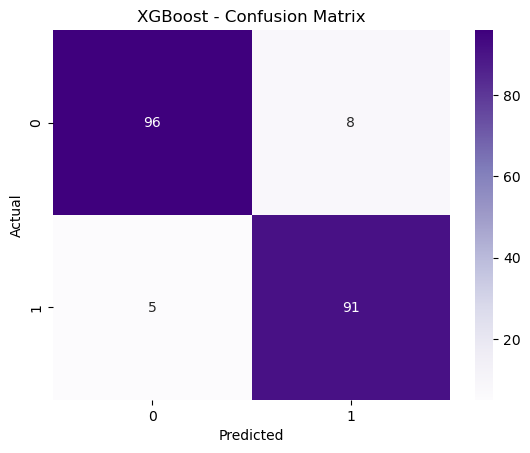

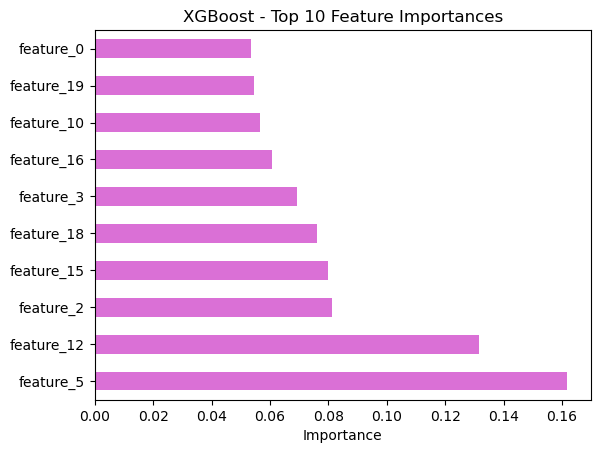

In [2]:
# %% [markdown]
# ## 0. Imports & Préparation

# Importation des bibliothèques nécessaires
import pandas as pd                      # Pour la manipulation des données
import numpy as np                       # Pour les opérations mathématiques et manipulation de tableaux
import matplotlib.pyplot as plt          # Pour les visualisations
import seaborn as sns                    # Pour des visualisations plus élégantes avec matplotlib

# Importation des fonctions utiles pour le machine learning
from sklearn.model_selection import train_test_split  # Pour diviser les données en train et test
from sklearn.metrics import accuracy_score, f1_score, recall_score, roc_auc_score, classification_report, confusion_matrix, roc_curve
# Pour évaluer les performances du modèle avec plusieurs métriques

from xgboost import XGBClassifier        # Importation du classifieur XGBoost

# %% [markdown]
# ## 1. Chargement des données

# Simuler un dataset de classification avec des données aléatoires
from sklearn.datasets import make_classification

# Création d’un dataset fictif avec 1000 exemples, 20 variables explicatives, dont 10 informatives
features, target = make_classification(n_samples=1000, n_features=20, n_informative=10, random_state=42)

# Conversion en DataFrame pour faciliter l’analyse et le traitement
features = pd.DataFrame(features, columns=[f'feature_{i}' for i in range(20)])

# %% [markdown]
# ## 2. Split des données

# Division des données en jeu d'entraînement (80%) et de test (20%)
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

# %% [markdown]
# ## 6bis. Entraînement du modèle XGBoost

# Création et configuration du modèle XGBoost
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

# Entraînement du modèle sur les données d’entraînement
xgb_model.fit(X_train, y_train)

# %% [markdown]
# ## 7bis. Prédictions et Évaluation

# Prédiction des classes sur les données de test
xgb_pred = xgb_model.predict(X_test)

# Prédiction des probabilités pour la classe positive (nécessaire pour certaines métriques comme ROC AUC)
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

# Affichage des différentes métriques d’évaluation
print("🎯 [XGBoost] Accuracy:", round(accuracy_score(y_test, xgb_pred), 2))          # Taux de bonne classification
print("📈 [XGBoost] F1 Score:", round(f1_score(y_test, xgb_pred), 2))                # Score F1
print("🔁 [XGBoost] Recall:", round(recall_score(y_test, xgb_pred), 2))              # Rappel (sensibilité)
print("📊 [XGBoost] ROC AUC:", round(roc_auc_score(y_test, xgb_prob), 2))            # AUC de la courbe ROC

# Affichage du rapport de classification complet
print("\nClassification Report:\n", classification_report(y_test, xgb_pred))

# %% [markdown]
# ## 8bis. Visualisations (XGBoost)

# ----------------------------
# 📌 1. Matrice de confusion
# ----------------------------
# Calcul et affichage de la matrice de confusion
cm = confusion_matrix(y_test, xgb_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples")  # Affichage avec Seaborn
plt.title("XGBoost - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ----------------------------
# 📌 2. Importance des variables
# ----------------------------
# Récupération de l’importance des variables à partir du modèle
xgb_importances = pd.Series(xgb_model.feature_importances_, index=features.columns)

# Affichage des 10 variables les plus importantes sous forme de graphique
xgb_importances.nlargest(10).plot(kind='barh', color='orchid')
plt.title("XGBoost - Top 10 Feature Importances")
plt.xlabel("Importance")
plt.show()

# ----------------------------
# 📌 3. Courbe ROC
# ----------------------------
# Calcul des taux de faux positifs et vrais positifs pour différents seuils
fpr, tpr, _ = roc_curve(y_test, xgb_prob)




In [4]:
bac_data.head()


,bac_id,id_et,nature_bac,date_bac,moy_bac_et,code_etab_bac
0,1,1,SPORT,2020-09-06,14.69,AVICENNE
1,2,10,ECOG,2018-04-24,14.74,HADIKA
2,3,100,LETT,2018-06-01,14.52,PRIVE_BORHEN
3,4,1000,ECOG,2019-10-17,12.89,PRIVE_BORHEN
4,5,101,LETT,2018-07-04,10.30,PRIVE_AL_HUSSEIN


# CLASSIFICATION KNN 

✅ Connected to database.
📊 Loaded 995 rows from Dim_bac.
🎯 [KNN] Accuracy: 0.64
📈 [KNN] F1 Score: 0.53
🔁 [KNN] Recall: 0.51
📊 [KNN] ROC AUC: 0.7

Classification Report:
               precision    recall  f1-score   support

           0       0.69      0.72      0.71       120
           1       0.55      0.51      0.53        80

    accuracy                           0.64       200
   macro avg       0.62      0.62      0.62       200
weighted avg       0.64      0.64      0.64       200



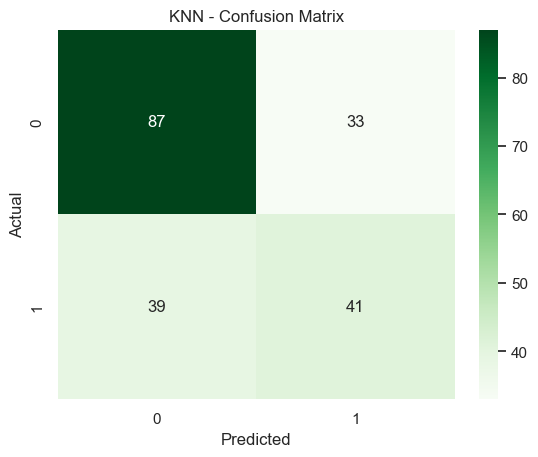

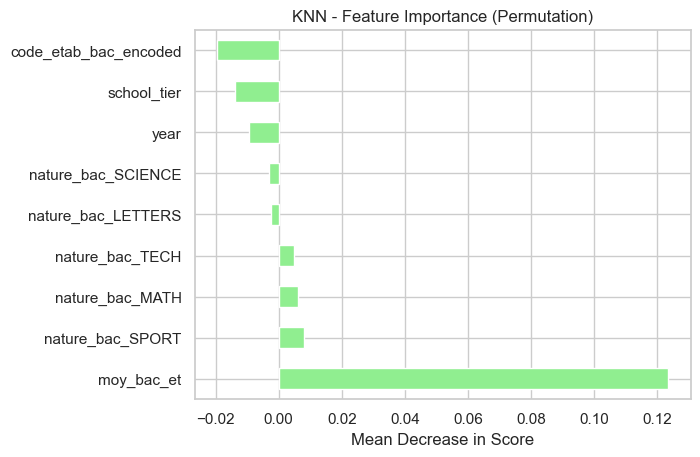

🧠 Admission Probability for New Student (KNN): 0.83
🔒 Connection closed.


In [3]:
# %% Imports
import pyodbc  # Pour se connecter à la base de données SQL Server
import pandas as pd  # Pour manipuler les données sous forme de DataFrame
import numpy as np  # Pour les opérations numériques et les simulations
import matplotlib.pyplot as plt  # Pour les visualisations
import seaborn as sns  # Pour des visualisations plus élégantes
from sklearn.neighbors import KNeighborsClassifier  # Algorithme KNN
from sklearn.model_selection import train_test_split  # Pour diviser les données en train/test
from sklearn.preprocessing import LabelEncoder  # Pour encoder les variables catégorielles
from sklearn.metrics import (  # Pour évaluer les performances du modèle
    accuracy_score, f1_score, recall_score, confusion_matrix, roc_auc_score,
    roc_curve, classification_report
)
from sklearn.inspection import permutation_importance  # Pour calculer l'importance des variables
import warnings  # Pour gérer les avertissements
warnings.filterwarnings('ignore')  # Ignorer les avertissements
sns.set(style="whitegrid")  # Style pour les graphiques seaborn

# %% Connexion base de données
def create_db_connection():
    server = 'LAPTOP-BJE2TQGI\\KK'  # Nom du serveur SQL
    database = 'add'  # Nom de la base de données
    conn_str = f'DRIVER={{SQL Server}};SERVER={server};DATABASE={database};Trusted_Connection=yes;'
    try:
        conn = pyodbc.connect(conn_str)  # Tenter de se connecter
        print("✅ Connected to database.")
        return conn
    except Exception as e:
        print(f"❌ Connection failed: {e}")
        return None

conn = create_db_connection()  # Connexion à la base de données

# %% Chargement données
def load_data(conn, table_name):
    try:
        df = pd.read_sql(f"SELECT * FROM {table_name}", conn)  # Charger les données depuis SQL
        print(f"📊 Loaded {len(df)} rows from {table_name}.")
        return df
    except Exception as e:
        print(f"❌ Load failed: {e}")
        return None

bac_data = load_data(conn, 'Dim_bac')  # Chargement des données de la table 'Dim_bac'

# %% Feature engineering
def prepare_features(df):
    df = df.copy()
    # Conversion de la date en format datetime
    if 'date_bac' in df.columns:
        df['date_bac'] = pd.to_datetime(df['date_bac'], errors='coerce')
        df['year'] = df['date_bac'].dt.year  # Extraire l’année
    # Nettoyage et conversion de la moyenne
    if 'moy_bac_et' in df.columns:
        df['moy_bac_et'] = df['moy_bac_et'].astype(str).str.replace(',', '.').astype(float)
    # Encodage de l’établissement
    if 'code_etab_bac' in df.columns:
        df['code_etab_bac_encoded'] = LabelEncoder().fit_transform(df['code_etab_bac'])
    # Création d’un indicateur du niveau de l’école (tiers)
    if 'code_etab_bac' in df.columns and 'moy_bac_et' in df.columns:
        school_avg = df.groupby('code_etab_bac')['moy_bac_et'].mean().sort_values()
        df['school_tier'] = df['code_etab_bac'].map({school: i // 3 for i, school in enumerate(school_avg.index)})
    return df

prepared_data = prepare_features(bac_data)  # Prétraitement des données

# %% Simuler données
def simulate_data(df, n=1000):
    df = df.sample(n, replace=True).copy()  # Échantillonnage aléatoire avec remise
    np.random.seed(42)
    # Simuler la moyenne avec du bruit aléatoire
    df['moy_bac_et'] = np.clip(df['moy_bac_et'] + np.random.normal(0, 1, n), 0, 20)
    # Modifier l’année aléatoirement
    df['year'] = df['year'] + np.random.randint(-2, 3, n)
    # Générer aléatoirement une nature de bac
    df['nature_bac'] = np.random.choice(['SCIENCE', 'LETTERS', 'MATH', 'SPORT', 'TECH'], n)
    # Générer une variable cible "admitted"
    df['admitted'] = ((df['moy_bac_et'] > 12) & (np.random.rand(n) > 0.3)).astype(int)
    return df

full_data = simulate_data(prepared_data)  # Simulation de données complètes

# %% Split données
# Sélection des features et encodage one-hot pour les variables catégorielles
features = pd.get_dummies(full_data[['moy_bac_et', 'school_tier', 'year', 'nature_bac', 'code_etab_bac_encoded']])
labels = full_data['admitted']  # Variable cible

# Séparation en jeu d'entraînement et de test (80/20)
X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size=0.2, random_state=42)

# %% Entraînement modèle KNN
knn_model = KNeighborsClassifier(n_neighbors=6)  # Modèle KNN avec 6 voisins
knn_model.fit(X_train, y_train)  # Entraînement du modèle

# %% Prédictions & Métriques
knn_pred = knn_model.predict(X_test)  # Prédictions sur les données de test
knn_prob = knn_model.predict_proba(X_test)[:, 1]  # Probabilités d’appartenance à la classe 1

# Affichage des métriques de performance
print("🎯 [KNN] Accuracy:", round(accuracy_score(y_test, knn_pred), 2))
print("📈 [KNN] F1 Score:", round(f1_score(y_test, knn_pred), 2))
print("🔁 [KNN] Recall:", round(recall_score(y_test, knn_pred), 2))
print("📊 [KNN] ROC AUC:", round(roc_auc_score(y_test, knn_prob), 2))
print("\nClassification Report:\n", classification_report(y_test, knn_pred))

# %% Matrice de confusion
cm = confusion_matrix(y_test, knn_pred)  # Matrice de confusion
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens")  # Affichage avec Seaborn
plt.title("KNN - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()



# %% Feature importance (Permutation)
# Importance des features par permutation
result = permutation_importance(knn_model, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)
perm_importances = pd.Series(result.importances_mean, index=features.columns)
perm_importances.nlargest(10).plot(kind='barh', color='lightgreen')  # Top 10 des features
plt.title("KNN - Feature Importance (Permutation)")
plt.xlabel("Mean Decrease in Score")
plt.show()

# %% Prédiction étudiant individuel
def predict_new_student(data, model, ref_columns):
    df = pd.DataFrame([data])  # Convertir dictionnaire en DataFrame
    df = prepare_features(df)  # Appliquer les mêmes transformations
    df = pd.get_dummies(df)  # Encodage one-hot
    # Ajouter les colonnes manquantes avec valeur 0
    for col in ref_columns:
        if col not in df.columns:
            df[col] = 0
    df = df[ref_columns]  # Réorganiser les colonnes dans le bon ordre
    proba = model.predict_proba(df)[0][1]  # Probabilité d'admission
    return round(proba, 2)

# Exemple d’un étudiant à prédire
new_student = {
    'moy_bac_et': 15.5,
    'school_tier': 1,
    'year': 2022,
    'nature_bac': 'SCIENCE',
    'code_etab_bac_encoded': 10
}
proba = predict_new_student(new_student, knn_model, features.columns)
print(f"🧠 Admission Probability for New Student (KNN): {proba}")

# %% Fermer connexion
conn.close()  # Fermer la connexion à la base de données
print("🔒 Connection closed.")
